***Semantic Paraphrase Identification on Quora Question Pairs Dataset Using Deep Learning***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import re

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI_FINAL_PROJECT/Dataset/questions.csv')

In [ ]:
df = df[['question1', 'question2', 'is_duplicate']]
df.dropna(inplace=True)

In [ ]:
df.head(10)

,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
5,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1
6,Should I buy tiago?,What keeps childern active and far from phone ...,0
7,How can I be a good geologist?,What should I do to be a great geologist?,1
8,When do you use シ instead of し?,"When do you use ""&"" instead of ""and""?",0
9,Motorola (company): Can I hack my Charter Moto...,How do I hack Motorola DCX3400 for free internet?,0


In [ ]:
df.shape

(404348, 3)

In [ ]:
#Text cleaning
def clean_text(x):
    x = x.lower()
    x = re.sub(r"[^a-z0-9? ]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

df["q1"] = df["question1"].apply(clean_text)
df["q2"] = df["question2"].apply(clean_text)
df["label"] = df["is_duplicate"].astype(int)

In [ ]:
#Build vocabulary
all_text = list(df["q1"]) + list(df["q2"])
words = " ".join(all_text).split()

counter = Counter(words)
vocab = {w: i+2 for i, (w, _) in enumerate(counter.items())}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

def text_to_tensor(text):
    return torch.tensor([vocab.get(w, 1) for w in text.split()], dtype=torch.long)

In [ ]:
#Custom dataset
class QQPDataset(Dataset):
    def __init__(self, df):
        self.q1 = df["q1"].values
        self.q2 = df["q2"].values
        self.y = df["label"].values

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        q1_tensor = text_to_tensor(self.q1[idx])
        q2_tensor = text_to_tensor(self.q2[idx])
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return q1_tensor, q2_tensor, label

def collate_fn(batch):
    q1, q2, y = zip(*batch)
    q1 = pad_sequence(q1, batch_first=True)
    q2 = pad_sequence(q2, batch_first=True)
    return q1, q2, torch.tensor(y)

In [ ]:
#Split and Dataloaders
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

train_ds = QQPDataset(train_df)
val_ds = QQPDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [ ]:
#LSTM model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim*4, 2)  # combine both q1 & q2 outputs

    def encode(self, x):
        emb = self.embedding(x)
        _, (h, _) = self.lstm(emb)
        return torch.cat((h[0], h[1]), dim=1)   # biLSTM output

    def forward(self, q1, q2):
        e1 = self.encode(q1)
        e2 = self.encode(q2)
        combined = torch.cat([e1, e2], dim=1)
        return self.fc(combined)

model = LSTMModel(vocab_size=len(vocab))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

LSTMModel(
  (embedding): Embedding(113336, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)

In [ ]:
#Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
#Training loop
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for q1, q2, y in tqdm(train_loader):
        q1, q2, y = q1.to(device), q2.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(q1, q2)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for q1, q2, y in val_loader:
            q1, q2, y = q1.to(device), q2.to(device), y.to(device)
            out = model(q1, q2)
            pred = torch.argmax(out, dim=1)
            preds.extend(pred.cpu().numpy())
            labels.extend(y.cpu().numpy())

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)

    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Acc={acc:.4f}, F1={f1:.4f}")

100%|██████████| 5687/5687 [01:16<00:00, 74.08it/s]


Epoch 1: Loss=299.851, Acc=0.7855, F1=0.7085


100%|██████████| 5687/5687 [01:16<00:00, 74.42it/s]


Epoch 2: Loss=281.061, Acc=0.7903, F1=0.7124


100%|██████████| 5687/5687 [01:16<00:00, 74.59it/s]


...

Epoch 8: Loss=191.923, Acc=0.7838, F1=0.7094


100%|██████████| 5687/5687 [01:16<00:00, 74.43it/s]


Epoch 9: Loss=180.688, Acc=0.7852, F1=0.7107


100%|██████████| 5687/5687 [01:16<00:00, 74.52it/s]


Epoch 10: Loss=182.489, Acc=0.7798, F1=0.7066


In [ ]:
#Save model
torch.save(model.state_dict(), "lstm_paraphrase_model.pth")
print("Model saved successfully!")

Model saved successfully!


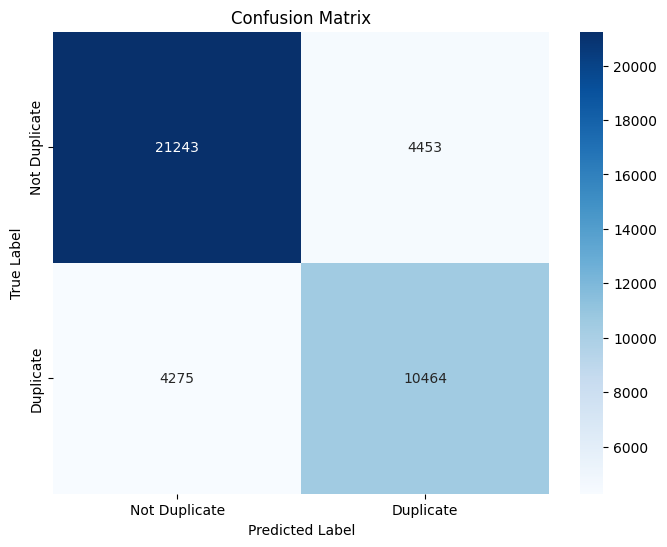

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Not Duplicate', 'Duplicate'],
            yticklabels=['Not Duplicate', 'Duplicate'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.eval()
all_probs = []

with torch.no_grad():
    for q1, q2, _ in val_loader: # We don't need y (labels) here for prediction
        q1, q2 = q1.to(device), q2.to(device)
        outputs = model(q1, q2)
        probabilities = torch.softmax(outputs, dim=1)
        all_probs.extend(probabilities[:, 1].cpu().numpy())

all_probs = np.array(all_probs)
print("Predicted probabilities on validation set generated.")

Predicted probabilities on validation set generated.


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(labels, all_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

ROC AUC Score: 0.8438


In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(labels, all_probs)

print("Calculated FPR, TPR, and thresholds for ROC curve.")

Calculated FPR, TPR, and thresholds for ROC curve.


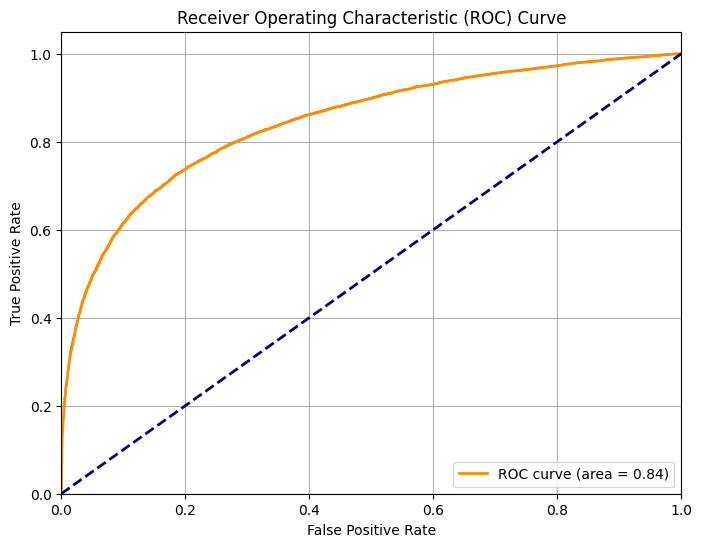

ROC AUC Score: 0.8438


In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [ ]:
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.7798
F1 Score: 0.7066
Precision: 0.6870
Recall: 0.7273


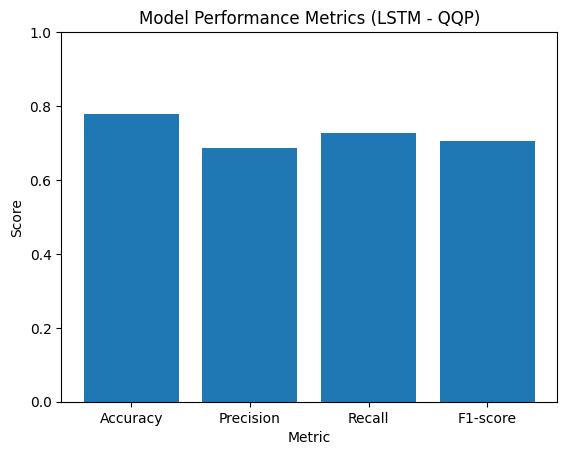

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [acc, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Model Performance Metrics (LSTM - QQP)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.show()

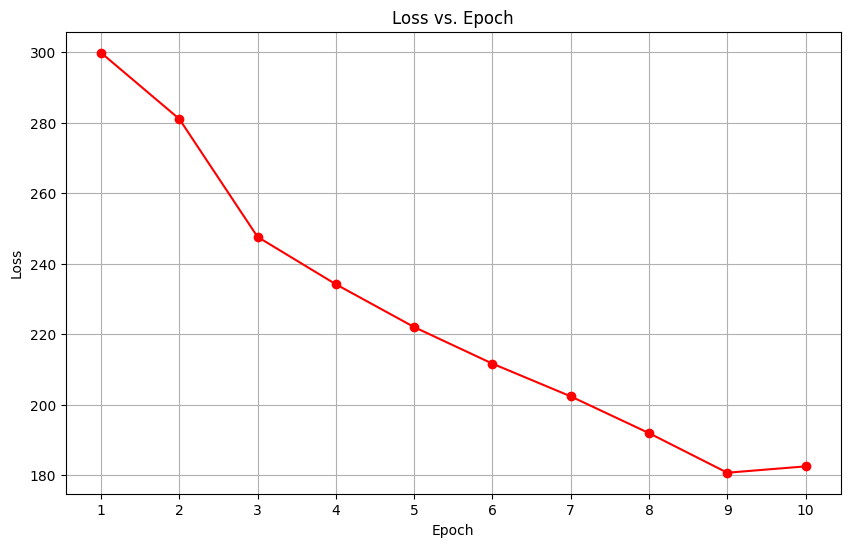

In [ ]:
import matplotlib.pyplot as plt
import re

training_output = """Epoch 1: Loss=299.851, Acc=0.7855, F1=0.7085
Epoch 2: Loss=281.061, Acc=0.7903, F1=0.7124
Epoch 3: Loss=247.600, Acc=0.7844, F1=0.7096
Epoch 4: Loss=234.159, Acc=0.7868, F1=0.7116
Epoch 5: Loss=222.013, Acc=0.7898, F1=0.7102
Epoch 6: Loss=211.638, Acc=0.7838, F1=0.7076
Epoch 7: Loss=202.355, Acc=0.7841, F1=0.7071
Epoch 8: Loss=191.923, Acc=0.7838, F1=0.7094
Epoch 9: Loss=180.688, Acc=0.7852, F1=0.7107
Epoch 10: Loss=182.489, Acc=0.7798, F1=0.7066"""

epochs_list = []
loss_list = []

for line in training_output.split('\n'):
    match = re.search(r"Epoch (\d+): Loss=(\d+\.\d+)", line)
    if match:
        epochs_list.append(int(match.group(1)))
        loss_list.append(float(match.group(2)))

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, loss_list, marker='o', linestyle='-', color='r')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(epochs_list)
plt.show()


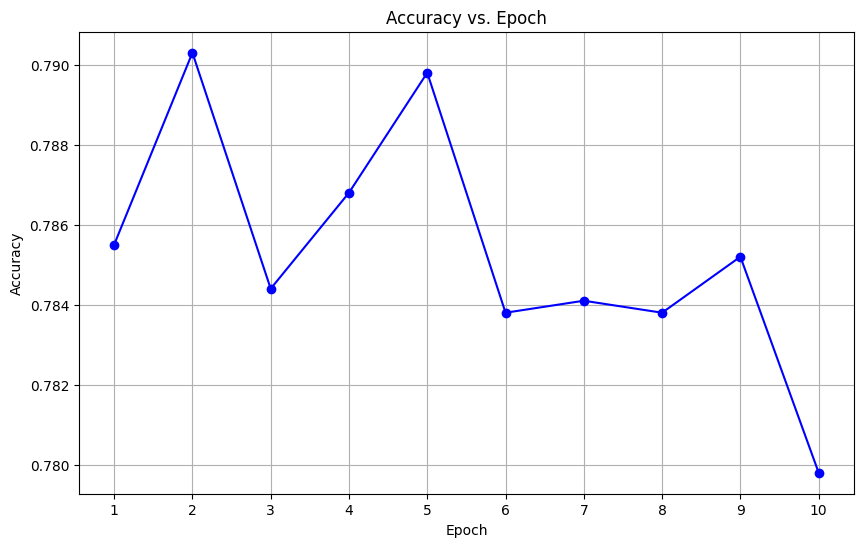

In [ ]:
import matplotlib.pyplot as plt
import re

training_output = """Epoch 1: Loss=299.851, Acc=0.7855, F1=0.7085
Epoch 2: Loss=281.061, Acc=0.7903, F1=0.7124
Epoch 3: Loss=247.600, Acc=0.7844, F1=0.7096
Epoch 4: Loss=234.159, Acc=0.7868, F1=0.7116
Epoch 5: Loss=222.013, Acc=0.7898, F1=0.7102
Epoch 6: Loss=211.638, Acc=0.7838, F1=0.7076
Epoch 7: Loss=202.355, Acc=0.7841, F1=0.7071
Epoch 8: Loss=191.923, Acc=0.7838, F1=0.7094
Epoch 9: Loss=180.688, Acc=0.7852, F1=0.7107
Epoch 10: Loss=182.489, Acc=0.7798, F1=0.7066"""

epochs_list = []
accuracy_list = []

for line in training_output.split('\n'):
    match = re.search(r"Epoch (\d+): .* Acc=(\d+\.\d+)", line)
    if match:
        epochs_list.append(int(match.group(1)))
        accuracy_list.append(float(match.group(2)))

plt.figure(figsize=(10, 6))
plt.plot(epochs_list, accuracy_list, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(epochs_list)
plt.show()
